In [73]:
import numpy as np

log2_L         = 0.1724

def log2(x):
    return np.log2(x)

def nb_filter_exp(alpha):
    """
    log2(NbFilters) / d
    V(alpha) ~ sin^d(alpha), ignoring poly(d) factors.
    """
    return -np.log2(np.sin(alpha))

def det_symmetric_all_equal(k, c):
    """
    Determinant of a k x k matrix with diagonal 1
    and all off-diagonal entries equal to c.
    """
    return (1 + (k - 1) * c) * (1 - c) ** (k - 1)

def c_prime_symmetric_all_equal(k, c, alpha):
    """
    Off-diagonal entry of C'(alpha) for a symmetric all-equal C.
    """
    s2 = np.sin(alpha) ** 2
    c2 = np.cos(alpha) ** 2
    return (c + c2 / (k - 1)) / s2

def nb_rep_exp_symmetric_all_equal(alpha, k, c):
    """
    log2(NbRep) / d for a symmetric all-equal configuration C.
    """
    cp = c_prime_symmetric_all_equal(k, c, alpha)
    detC = det_symmetric_all_equal(k, c)
    detCp = det_symmetric_all_equal(k, cp)

    val = (
        0.5 * np.log2(detC)
        - (k - 1) * np.log2(np.sin(alpha))
        - 0.5 * np.log2(detCp)
    )
    return max(0.0, val)

def qrw_cost_N_units(n1, Cprime, c, c1, c2, rho):
    """Returns (T_QRW_log2_in_N_units, diagnostics) or (None, None)."""
    if abs(Cprime) >= 1:
        return None, None
    log2_psol = 0.5 * np.log2(1 - Cprime**2)
    theta_prime = np.arccos(Cprime)

    log2_sin_beta = (c2 - c1) * n1
    if log2_sin_beta > 0:
        return None, None
    sin_beta = 2.0**log2_sin_beta
    cos2_beta = 1.0 - sin_beta**2

    denom = 1.0 + np.cos(theta_prime)
    if denom <= 0:
        return None, None
    ratio = 2.0 * cos2_beta / denom
    if ratio >= 1:
        return None, None
    log2_W = 0.5 * np.log2(1 - ratio)

    rho0 = (log2_sin_beta - log2_W) / n1
    if rho0 < 0 or rho > rho0 + 1e-9:
        return None, None

    zeta = 2 * c + log2_psol / n1
    if zeta <= 0:
        return None, None

    log2_eps = 2 * c1 + log2_psol / n1 + rho - rho0
    S_log2 = c1 + rho
    U_log2 = max(rho, (rho + c2) / 2.0)
    delta_log2 = -c1

    inv_sqrt_eps   = -0.5 * log2_eps
    inv_sqrt_delta = -0.5 * delta_log2
    term = inv_sqrt_delta + U_log2
    T1_log2 = max(S_log2, inv_sqrt_eps + max(term, 0.0))
    FAS1_log2 = max(zeta, 0.0) + T1_log2
    NbRep_QRW_log2 = max(0.0, c - zeta)
    inner = max(1.0, (1 - c) + FAS1_log2)

    T_QRW_log2 = NbRep_QRW_log2 + inner
    diag = dict(
        c=c, c1=c1, c2=c2, rho=rho,
        rho0=rho0, zeta=zeta, log2_eps=log2_eps,
        S=S_log2, U=U_log2, delta=delta_log2,
        T1=T1_log2, FAS1=FAS1_log2,
        NbRep_QRW=NbRep_QRW_log2,
    )
    return T_QRW_log2, diag


def full_hybrid_time(alpha0, s, c):
    Cprime = (c + (1 - s) / 3.0) / s
    if abs(Cprime) >= 1:
        return None
    log2_Ri = log2_L + 0.5 * np.log2(s)
    if log2_Ri < 0:
        return None
    n1 = log2_Ri

    log2_p12 = 0.5 * np.log2(1 - Cprime**2)
    E12 = 2 * log2_Ri + log2_p12
    if E12 < 0:
        return None

    Ceff = s / (4.0 * (1 + c)) - 1.0
    if abs(Ceff) >= 1:
        return None
    log2_psol3 = 0.5 * np.log2(1 - Ceff**2)
    m = 2 * E12 + log2_psol3

    T1234_log2 = 2 * E12 + 0.5 * log2_psol3 if m >= 0 else E12

    # ---- optimize the QRW parameters for the first two calls ----
    best_T12_N   = None
    best_diag    = None
    for c_qrw in np.linspace(0.05, 0.95, 25):
        for c1 in np.linspace(0.02, c_qrw, 25):
            for c2 in (0.0, c1):
                if c1 == c2:
                    continue
                for rho in (0.0, 0.05, 0.1, 0.15):
                    T, diag = qrw_cost_N_units(n1, Cprime, c_qrw, c1, c2, rho)
                    if T is None:
                        continue
                    if best_T12_N is None or T < best_T12_N:
                        best_T12_N = T
                        best_diag  = diag
    if best_T12_N is None:
        return None

    T12_log2 = n1 * best_T12_N
    T34_log2 = T12_log2
    T_filter_log2 = max(T12_log2, T34_log2, T1234_log2)
    T_hybrid_log2 = nb_filter_exp(alpha0) + nb_rep_exp_symmetric_all_equal(alpha0, 4, c) + T_filter_log2

    return dict(
        # --- outer 4-sieve quantities ---
        Cprime=Cprime, E12=E12, Ceff=Ceff,
        log2_Ri=log2_Ri, n1=n1,
        log2_p12=log2_p12, log2_psol3=log2_psol3,
        m=m,
        # --- times (in exponents of d) ---
        T12=T12_log2, T34=T34_log2, T1234=T1234_log2,
        T_filter=T_filter_log2, T_hybrid=T_hybrid_log2,
        # --- QRW parameters for the first two inner calls ---
        qrw=best_diag,
    )


# ---------------------------------------------------------------
# Grid search for the optimum with M >= 1
# ---------------------------------------------------------------
best = None
for alpha0 in np.linspace(1.20, np.pi/2, 80):
    s = np.sin(alpha0)**2
    C12=-0.25
    res = full_hybrid_time(alpha0, s, C12)
    if res is None:
        continue
    if res['m'] < 0:            # require M >= 1
        continue
    if best is None or res['T_hybrid'] < best[0]:
        best = (res['T_hybrid'], alpha0, C12, res)

if best is None:
    print("No feasible point found.")
else:
    T_hy, a0, C12, res = best
    print("=" * 60)
    print("OPTIMUM (per-filter M >= 1)")
    print("=" * 60)
    print(f"alpha0 = {a0:.6f} rad      (s = sin^2(alpha0) = {np.sin(a0)**2:.6f})")
    print(f"C12    = {C12:.6f}")
    print()
    print("--- derived outer-sieve quantities ---")
    print(f"C'12           = {res['Cprime']:.6f}")
    print(f"|R_i|  exponent= {res['log2_Ri']:.6f}  (i.e. |R_i| = 2^{res['log2_Ri']:.4f} d)")
    print(f"|L12|  exponent= {res['E12']:.6f}")
    print(f"C_eff          = {res['Ceff']:.6f}")
    print(f"p_sol          = 2^{res['log2_psol3']:.6f} d")
    print(f"p_12           = 2^{res['log2_p12']:.6f} d")
    print(f"M (sols/filter)= 2^{res['m']:.6f} d")
    print()
    print("--- running-time exponents (in 2^{e d}) ---")
    print(f"T12  = {res['T12']:.6f}")
    print(f"T34  = {res['T34']:.6f}")
    print(f"T1234= {res['T1234']:.6f}")
    print(f"T_filter = {res['T_filter']:.6f}")
    print(f"T_hybrid = {res['T_hybrid']:.6f}")
    print()
    print("--- QRW parameters for the first two inner calls ---")
    q = res['qrw']
    print(f"c     = {q['c']:.4f}")
    print(f"c_1   = {q['c1']:.4f}")
    print(f"c_2   = {q['c2']:.4f}")
    print(f"rho   = {q['rho']:.4f}")
    print()
    print("--- QRW derived quantities ---")
    print(f"rho_0 = {q['rho0']:.6f}")
    print(f"zeta  = {q['zeta']:.6f}")
    print(f"S     = N^{q['S']:.6f}")
    print(f"U     = N^{q['U']:.6f}")
    print(f"delta = N^{q['delta']:.6f}")
    print(f"T1    = N^{q['T1']:.6f}")
    print(f"FAS1  = N^{q['FAS1']:.6f}")
    print(f"NbRep_QRW = N^{q['NbRep_QRW']:.6f}")
    print(f"T_QRW (in N units) = N^{q['T1']:.6f}  ...  see T12 for d-units")

OPTIMUM (per-filter M >= 1)
alpha0 = 1.350196 rad      (s = sin^2(alpha0) = 0.952120)
C12    = -0.250000

--- derived outer-sieve quantities ---
C'12           = -0.245809
|R_i|  exponent= 0.137008  (i.e. |R_i| = 2^0.1370 d)
|L12|  exponent= 0.229057
C_eff          = -0.682627
p_sol          = 2^-0.452516 d
p_12           = 2^-0.044958 d
M (sols/filter)= 2^0.005598 d

--- running-time exponents (in 2^{e d}) ---
T12  = 0.159486
T34  = 0.159486
T1234= 0.231856
T_filter = 0.231856
T_hybrid = 0.345301

--- QRW parameters for the first two inner calls ---
c     = 0.2000
c_1   = 0.0500
c_2   = 0.0500
rho   = 0.0000

--- QRW derived quantities ---
rho_0 = 0.000000
zeta  = 0.071859
S     = N^0.050000
U     = N^0.025000
delta = N^-0.050000
T1    = N^0.164070
FAS1  = N^0.235930
NbRep_QRW = N^0.128141
T_QRW (in N units) = N^0.164070  ...  see T12 for d-units


In [71]:
# import numpy as np


# alpha4 = 1.350196     # rad
# k4 = 4
# c4 = -0.25     # valid because c > -1/3 for k=4

# print("4-sieve symmetric all-equal:")
# print("NbFilter exponent:", nb_filter_exp(alpha4))
# print("NbRep exponent:   ", nb_rep_exp_symmetric_all_equal(alpha4, k4, c4))

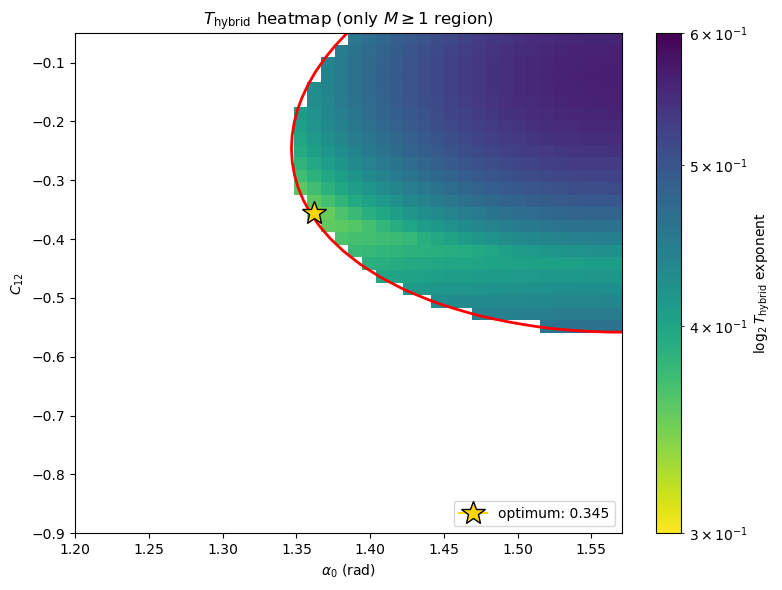

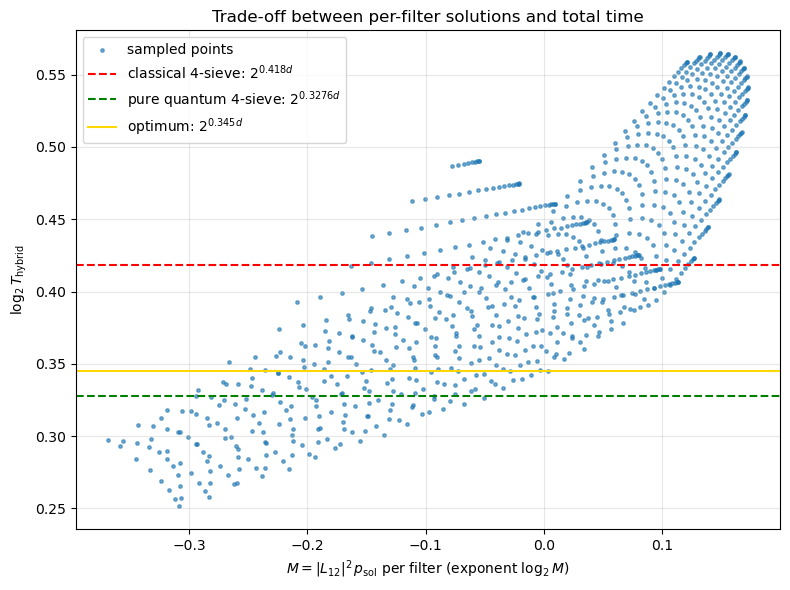

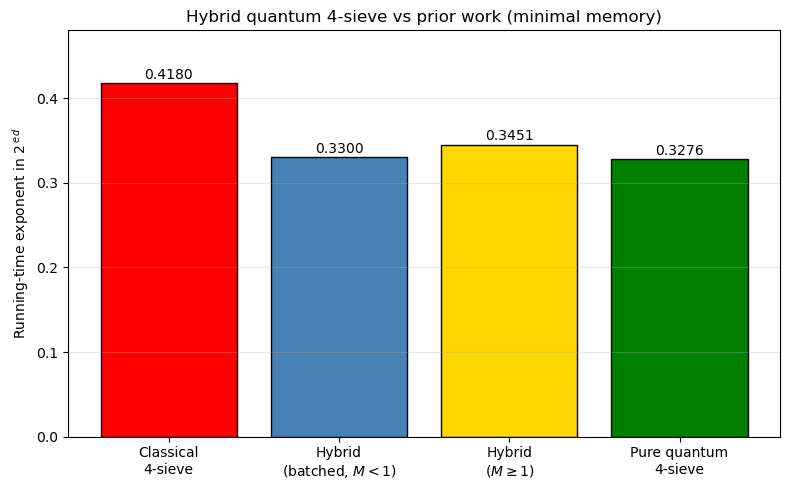

Best T_hybrid exponent: 0.3451339626898883
alpha0 = 1.3616291680900832  C12 = -0.3551282051282052  M = 0.003467196786830773


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ------------------------------------------------------------------
# Constants
# ------------------------------------------------------------------
log2_L         = 0.1724

def log2(x):
    return np.log2(x)

def nb_filter_exp(alpha):
    """
    log2(NbFilters) / d
    V(alpha) ~ sin^d(alpha), ignoring poly(d) factors.
    """
    return -np.log2(np.sin(alpha))

def det_symmetric_all_equal(k, c):
    """
    Determinant of a k x k matrix with diagonal 1
    and all off-diagonal entries equal to c.
    """
    return (1 + (k - 1) * c) * (1 - c) ** (k - 1)

def c_prime_symmetric_all_equal(k, c, alpha):
    """
    Off-diagonal entry of C'(alpha) for a symmetric all-equal C.
    """
    s2 = np.sin(alpha) ** 2
    c2 = np.cos(alpha) ** 2
    return (c + c2 / (k - 1)) / s2

def nb_rep_exp_symmetric_all_equal(alpha, k, c):
    """
    log2(NbRep) / d for a symmetric all-equal configuration C.
    """
    cp = c_prime_symmetric_all_equal(k, c, alpha)
    detC = det_symmetric_all_equal(k, c)
    detCp = det_symmetric_all_equal(k, cp)

    val = (
        0.5 * np.log2(detC)
        - (k - 1) * np.log2(np.sin(alpha))
        - 0.5 * np.log2(detCp)
    )
    return max(0.0, val)

# ------------------------------------------------------------------
# QRW cost (in units of the list size N1)
# ------------------------------------------------------------------
def qrw_cost_N_units(n1, Cprime, c, c1, c2, rho):
    if abs(Cprime) >= 1:
        return None
    log2_psol = 0.5 * np.log2(1 - Cprime**2)
    theta_prime = np.arccos(Cprime)

    log2_sin_beta = (c2 - c1) * n1
    if log2_sin_beta > 0:
        return None
    sin_beta = 2.0**log2_sin_beta
    cos2_beta = 1.0 - sin_beta**2

    denom = 1.0 + np.cos(theta_prime)
    if denom <= 0:
        return None
    ratio = 2.0 * cos2_beta / denom
    if ratio >= 1:
        return None
    log2_W = 0.5 * np.log2(1 - ratio)

    rho0 = (log2_sin_beta - log2_W) / n1
    if rho0 < 0 or rho > rho0 + 1e-9:
        return None

    zeta = 2 * c + log2_psol / n1
    if zeta <= 0:
        return None

    log2_eps = 2 * c1 + log2_psol / n1 + rho - rho0
    S_log2 = c1 + rho
    U_log2 = max(rho, (rho + c2) / 2.0)
    delta_log2 = -c1

    inv_sqrt_eps   = -0.5 * log2_eps
    inv_sqrt_delta = -0.5 * delta_log2
    term = inv_sqrt_delta + U_log2
    T1_log2 = max(S_log2, inv_sqrt_eps + max(term, 0.0))
    FAS1_log2 = max(zeta, 0.0) + T1_log2
    NbRep_QRW_log2 = max(0.0, c - zeta)
    inner = max(1.0, (1 - c) + FAS1_log2)
    return NbRep_QRW_log2 + inner


# ------------------------------------------------------------------
# Full hybrid time
# ------------------------------------------------------------------
def full_hybrid_time(s, c):
    Cprime = (c + (1 - s) / 3.0) / s
    if abs(Cprime) >= 1:
        return None
    log2_Ri = log2_L + 0.5 * np.log2(s)
    if log2_Ri < 0:
        return None
    n1 = log2_Ri

    log2_p12 = 0.5 * np.log2(1 - Cprime**2)
    E12 = 2 * log2_Ri + log2_p12
    if E12 < 0:
        return None

    Ceff = s / (4.0 * (1 + c)) - 1.0
    if abs(Ceff) >= 1:
        return None
    log2_psol3 = 0.5 * np.log2(1 - Ceff**2)
    m = 2 * E12 + log2_psol3

    T1234_log2 = 2 * E12 + 0.5 * log2_psol3 if m >= 0 else E12

    best_T12_N = None
    for c_qrw in np.linspace(0.05, 0.95, 20):
        for c1 in np.linspace(0.02, c_qrw, 20):
            for c2 in (0.0, 0.05):
                for rho in (0.0, 0.05, 0.1, 0.15):
                    T = qrw_cost_N_units(n1, Cprime, c_qrw, c1, c2, rho)
                    if T is None:
                        continue
                    if best_T12_N is None or T < best_T12_N:
                        best_T12_N = T
    if best_T12_N is None:
        return None

    T12_log2 = n1 * best_T12_N
    T34_log2 = T12_log2
    T_filter_log2 = max(T12_log2, T34_log2, T1234_log2)
    T_hybrid_log2 = nb_filter_exp(alpha0) + nb_rep_exp_symmetric_all_equal(alpha0, 4, c) + T_filter_log2

    return dict(Cprime=Cprime, E12=E12, Ceff=Ceff, m=m,
                T12=T12_log2, T34=T34_log2, T1234=T1234_log2,
                T_filter=T_filter_log2, T_hybrid=T_hybrid_log2)


# ------------------------------------------------------------------
# Scan grid
# ------------------------------------------------------------------
alphas = np.linspace(1.20, np.pi/2, 40)
C12s   = np.linspace(-0.90, -0.05, 40)

TH = np.full((len(C12s), len(alphas)), np.nan)   # T_hybrid
MM = np.full_like(TH, np.nan)                    # M per filter
T1 = np.full_like(TH, np.nan)
T3 = np.full_like(TH, np.nan)

for i, c in enumerate(C12s):
    for j, a in enumerate(alphas):
        s = np.sin(a) ** 2
        res = full_hybrid_time(s, c)
        if res is None:
            continue
        TH[i, j] = res['T_hybrid']
        MM[i, j] = res['m']
        T1[i, j] = res['T12']
        T3[i, j] = res['T1234']

# ------------------------------------------------------------------
# Plot 1: heatmap of T_hybrid with M=1 contour
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.isfinite(TH) & (MM >= 0)     # only M >= 1 (per-filter feasible)
TH_masked = np.where(mask, TH, np.nan)

im = ax.imshow(
    TH_masked, origin='lower', aspect='auto',
    extent=[alphas[0], alphas[-1], C12s[0], C12s[-1]],
    cmap='viridis_r', norm=LogNorm(vmin=0.30, vmax=0.60)
)
ax.contour(alphas, C12s, MM, levels=[0.0], colors='red', linewidths=2)

# mark the optimum
best = (np.inf, None, None, None)
for i, c in enumerate(C12s):
    for j, a in enumerate(alphas):
        if np.isfinite(TH[i, j]) and MM[i, j] >= 0 and TH[i, j] < best[0]:
            best = (TH[i, j], a, c, MM[i, j])

ax.plot(best[1], best[2], marker='*', markersize=18, color='gold',
        markeredgecolor='black', label=f'optimum: {best[0]:.3f}')

ax.set_xlabel(r'$\alpha_0$ (rad)')
ax.set_ylabel(r'$C_{12}$')
ax.set_title(r'$T_{\mathrm{hybrid}}$ heatmap (only $M \geq 1$ region)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\log_2 T_{\mathrm{hybrid}}$ exponent')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('heatmap_Thybrid.png', dpi=200)
plt.show()

# ------------------------------------------------------------------
# Plot 2: trade-off T_hybrid vs M per filter
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
m_vals = MM[np.isfinite(MM) & np.isfinite(TH)]
t_vals = TH[np.isfinite(MM) & np.isfinite(TH)]
ax.scatter(m_vals, t_vals, s=6, alpha=0.6, label='sampled points')

# horizontal reference lines
ax.axhline(0.4180, color='red',    linestyle='--', label=r'classical 4-sieve: $2^{0.418d}$')
ax.axhline(0.3276, color='green',  linestyle='--', label=r'pure quantum 4-sieve: $2^{0.3276d}$')
ax.axhline(best[0], color='gold',  linestyle='-',  label=f'optimum: $2^{{{best[0]:.3f}d}}$')

ax.set_xlabel(r'$M = |L_{12}|^2\, p_{\mathrm{sol}}$ per filter (exponent $\log_2 M$)')
ax.set_ylabel(r'$\log_2 T_{\mathrm{hybrid}}$')
ax.set_title(r'Trade-off between per-filter solutions and total time')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tradeoff_M_Thybrid.png', dpi=200)
plt.show()

# ------------------------------------------------------------------
# Plot 3: comparison bar chart
# ------------------------------------------------------------------
labels = ['Classical\n4-sieve', 'Hybrid\n(batched, $M<1$)', 
          'Hybrid\n($M\\geq 1$)', 'Pure quantum\n4-sieve']
values = [0.418, 0.330, best[0], 0.3276]
colors = ['red', 'steelblue', 'gold', 'green']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='black')
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005,
            f'{v:.4f}', ha='center', fontsize=10)
ax.set_ylabel(r'Running-time exponent in $2^{\,e\,d}$')
ax.set_title('Hybrid quantum 4-sieve vs prior work (minimal memory)')
ax.set_ylim(0, 0.48)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_bars.png', dpi=200)
plt.show()

print("Best T_hybrid exponent:", best[0])
print("alpha0 =", best[1], " C12 =", best[2], " M =", best[3])